In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal
from rockpool.devices.xylo.syns63300.imuif import RotationRemoval
from rockpool.devices.xylo.syns63300 import Quantizer

import argparse
from tqdm.autonotebook import tqdm as notebook_tqdm

/home/igavier_umass_edu/.conda/envs/xyloIMU/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sampleFreq = 64
subjID = 1

In [33]:
# Load dataframe
P = np.load('/work/pi_sunghoonlee_umass_edu/Ignacio/realworld/pid.npy')
X = np.load('/work/pi_sunghoonlee_umass_edu/Ignacio/realworld/X.npy')
Y = np.load('/work/pi_sunghoonlee_umass_edu/Ignacio/realworld/Y.npy')

In [34]:
np.unique(Y)

array(['climbingdown', 'climbingup', 'jumping', 'lying', 'running',
       'sitting', 'standing', 'walking'], dtype='<U12')

[3 3 2 2 1 2 1 1 2 2 2 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


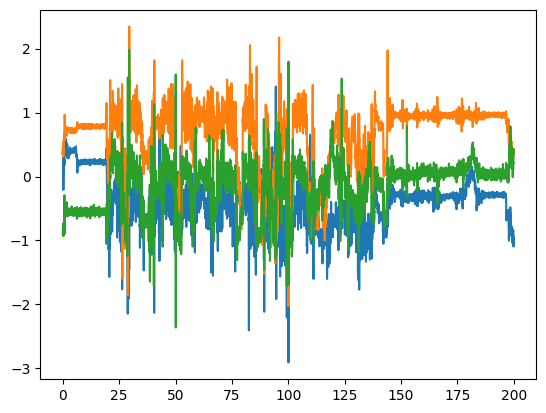

In [39]:
init, finl = 0, 20
fs = X.shape[1] // 10
plt.plot(np.arange((finl-init)*10*fs) / fs, X[init:finl].reshape(-1,3))
print(Y[init:finl])
print(P[init:finl])

In [1]:
import sys
sys.path.append('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/')
from datasets import *
from architectures import *

use_xylo = False
polarity_bichannel = True
time_compress = 1.0
random_seed = 1
subject_splits = (10, 2, 2)
label_type = 'Willetts2018'
data_path = (f'/work/pi_sunghoonlee_umass_edu/Ignacio/realworld/' +
             f'data/{"eventsNIMU" if not use_xylo else "spikesXylo"}/windows/')

# Create transforms for the dataset
transform1 = polarityBichannel() if polarity_bichannel else lambda x: x
transform2 = compressSpikes(factor=time_compress) if time_compress != 1.0 else lambda x: x
transforms = lambda x: transform2(transform1(x))

# Create datasets and balance among classes
dataset_class = REALWORLD
dataset_train = dataset_class(data_path, split='train', subject_splits=subject_splits,
                              transform=transforms, label_type=label_type, seed=random_seed)
dataset_train.balance()
dataset_val = dataset_class(data_path,split='val', subject_splits=subject_splits,
                            transform=transforms, label_type=label_type, seed=random_seed)
dataset_val.balance()
dataset_test = dataset_class(data_path, split='test', subject_splits=subject_splits,
                             transform=transforms, label_type=label_type, seed=random_seed)
dataset_test.balance()

RuntimeError: Some class missing: [0 0 0 0 0 0 0 0]

In [3]:
import sys
sys.path.append('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/')
from datasets import *
from architectures import *
from torch.utils.data import DataLoader

In [22]:
use_xylo = True
polarity_bichannel = False
time_compress = 1.0
dataset_name = 'Realworld'
data_path = (f'/work/pi_sunghoonlee_umass_edu/Ignacio/{dataset_name.lower()}/' +
             f'data/{"eventsNIMU" if not use_xylo else "spikesXylo"}/windows/')
subject_splits = (10, 2, 2)
label_type = 'Willetts2018'
random_seed = 1
batch_size = 128

# Create transforms for the dataset
transform1 = polarityBichannel() if polarity_bichannel else lambda x: x
transform2 = compressSpikes(factor=time_compress) if time_compress != 1.0 else lambda x: x
transforms = lambda x: transform2(transform1(x))

# Create datasets and balance among classes
dataset_class = {'Capture24':CAPTURE24, 'ADL':ADL, 'Opportunity':OPPORTUNITY,
                 'PAMAP':PAMAP, 'Realworld':REALWORLD, 'Wisdm':WISDM}[dataset_name]
dataset_train = dataset_class(data_path, split='train', subject_splits=subject_splits,
                              transform=transforms, label_type=label_type, seed=random_seed)
dataset_train.balance()
dataset_val = dataset_class(data_path,split='val', subject_splits=subject_splits,
                            transform=transforms, label_type=label_type, seed=random_seed)
dataset_val.balance()
dataset_test = dataset_class(data_path, split='test', subject_splits=subject_splits,
                             transform=transforms, label_type=label_type, seed=random_seed)
dataset_test.balance()

# Create data loaders
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)

In [28]:
te_inputs, te_labels = [], []
for (inputs, labels) in test_loader:
    inputs = inputs.to(dtype=torch.float) # (N, T, 15)
    labels = labels.to(dtype=torch.long) # (N, C)
    
    te_inputs.append(inputs.detach().numpy())
    te_labels.append(labels.detach().numpy())

te_inputs = np.concatenate(te_inputs, axis=0)
te_labels = np.concatenate(te_labels, axis=0)

In [29]:
np.save('./Xylo_test_inputs.npy', te_inputs)
np.save('./Xylo_test_labels.npy', te_labels)